# Tutorial: Entendiendo los Embeddings de Google AI

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Embeddings.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

## 1. Introducción a los Embeddings

### ¿Qué son los embeddings?

Los embeddings son representaciones numéricas que capturan relaciones semánticas entre diferentes entradas. En el contexto de texto, los embeddings convierten palabras, frases o documentos en vectores (arrays de números de punto flotante) que representan su significado en un espacio multidimensional.

### ¿Por qué son importantes?

Los embeddings permiten a las computadoras "entender" el significado de los textos de manera que:
- Textos con significados similares tendrán vectores cercanos en el espacio vectorial
- Se pueden realizar operaciones matemáticas con estos vectores para realizar tareas como búsqueda semántica, clasificación, clustering, etc.
- Sirven como base para sistemas avanzados como RAG (Retrieval Augmented Generation)

### Características de los embeddings de Google AI

- Generan vectores de alta calidad que capturan la semántica del texto
- Permiten dimensionalidad configurable (hasta 3072 dimensiones)
- Ofrecen tipos de tareas específicas para optimizar diferentes casos de uso
- Se integran fácilmente con la API de Gemini

## 2. Configuración del entorno

Para usar los embeddings de Google AI, necesitamos configurar nuestro entorno de trabajo.

In [ ]:
# Instalamos la biblioteca de Google GenAI
%pip install -q -U "google-genai>=1.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 10.2 MB/s eta 0:00:00


### Configuración de la API Key

Para utilizar la API de Google AI, necesitamos una clave API. Si estás en Colab, puedes almacenarla como un secreto.

In [ ]:
# Si estás en Colab, puedes usar este método para acceder a tu clave API
from google.colab import userdata

# Obtener la clave API desde los secretos de Colab
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# Alternativa: si no estás en Colab, puedes asignar tu clave API directamente
# GEMINI_API_KEY = "TU_CLAVE_API_AQUÍ"  # ¡No incluyas esto en código compartido!

### Inicialización del cliente

Ahora inicializamos el cliente de Google GenAI con nuestra clave API.

In [ ]:
from google import genai

# Inicializar el cliente con tu clave API
client = genai.Client(api_key=GEMINI_API_KEY)

# Seleccionar el modelo de embeddings que usaremos
MODEL_ID = "gemini-embedding-001"  # También podemos usar "text-embedding-004"

## 3. Generando nuestro primer embedding

Vamos a crear un embedding para una frase simple para entender el proceso básico.

In [ ]:
# Texto de ejemplo
texto = ["Hola mundo, suscribete al canal"]

# Generamos el embedding
resultado = client.models.embed_content(model=MODEL_ID, contents=texto)
[embedding] = resultado.embeddings

# Imprimimos una parte del embedding para visualizar
print(f"Primeros 10 valores del embedding: {embedding.values[:10]}")
print(f"\nLongitud total del embedding: {len(embedding.values)}")

Primeros 10 valores del embedding: [-0.024278073, 0.011784033, 5.4527627e-06, -0.0580776, -0.012595868, 0.033024922, -0.012462286, 0.018068938, -0.0040808367, 0.0022901078]

Longitud total del embedding: 3072


### ¿Qué acabamos de ver?

- Utilizamos la función `embed_content` que convierte texto en vectores numéricos
- El modelo generó un vector de 3072 dimensiones (valores)
- Cada número en este vector representa una característica abstracta del significado del texto
- Este vector es la "huella digital semántica" de nuestro texto

## 4. Embeddings por lotes (batch)

Una característica poderosa es la capacidad de generar embeddings para múltiples textos en una sola llamada a la API. Esto es mucho más eficiente que procesar cada texto individualmente.

In [ ]:
# Lista de varios textos
textos = [
    'La inteligencia artificial está revolucionando muchos campos.',
    'Los embeddings son representaciones vectoriales del significado.',
    'El aprendizaje automático requiere grandes cantidades de datos.'
]

# Generamos embeddings para todos los textos en una sola llamada
resultado_batch = client.models.embed_content(
    model=MODEL_ID,
    contents=textos
)

# Imprimimos información sobre los embeddings generados
print(f"Número de embeddings generados: {len(resultado_batch.embeddings)}")

# Mostramos los primeros 5 valores de cada embedding
for i, embedding in enumerate(resultado_batch.embeddings):
    print(f"\nEmbedding {i+1} (primeros 5 valores): {embedding.values[:5]}")

Número de embeddings generados: 3

Embedding 1 (primeros 5 valores): [-0.014353994, 0.00044689374, 0.017758222, -0.067130685, -0.016134083]

Embedding 2 (primeros 5 valores): [-0.012856509, -0.010445021, 0.004463054, -0.074098885, -0.00899174]

Embedding 3 (primeros 5 valores): [-0.01769482, 0.0034487233, 0.019769194, -0.052169867, -0.005699533]


### Ventajas del procesamiento por lotes

- **Eficiencia**: Reducción significativa en el tiempo total de procesamiento
- **Reducción de costos**: Menos llamadas a la API significa menor costo
- **Consistencia**: Los embeddings se generan en el mismo contexto del modelo

## 5. Configurando la dimensionalidad de los embeddings

Los modelos de embeddings de Google AI permiten configurar la dimensionalidad (número de valores) del vector resultante. Esto es útil cuando:

- Necesitas optimizar el almacenamiento
- Quieres reducir el tiempo de cálculo de similitud
- Estás experimentando con el equilibrio entre precisión y eficiencia

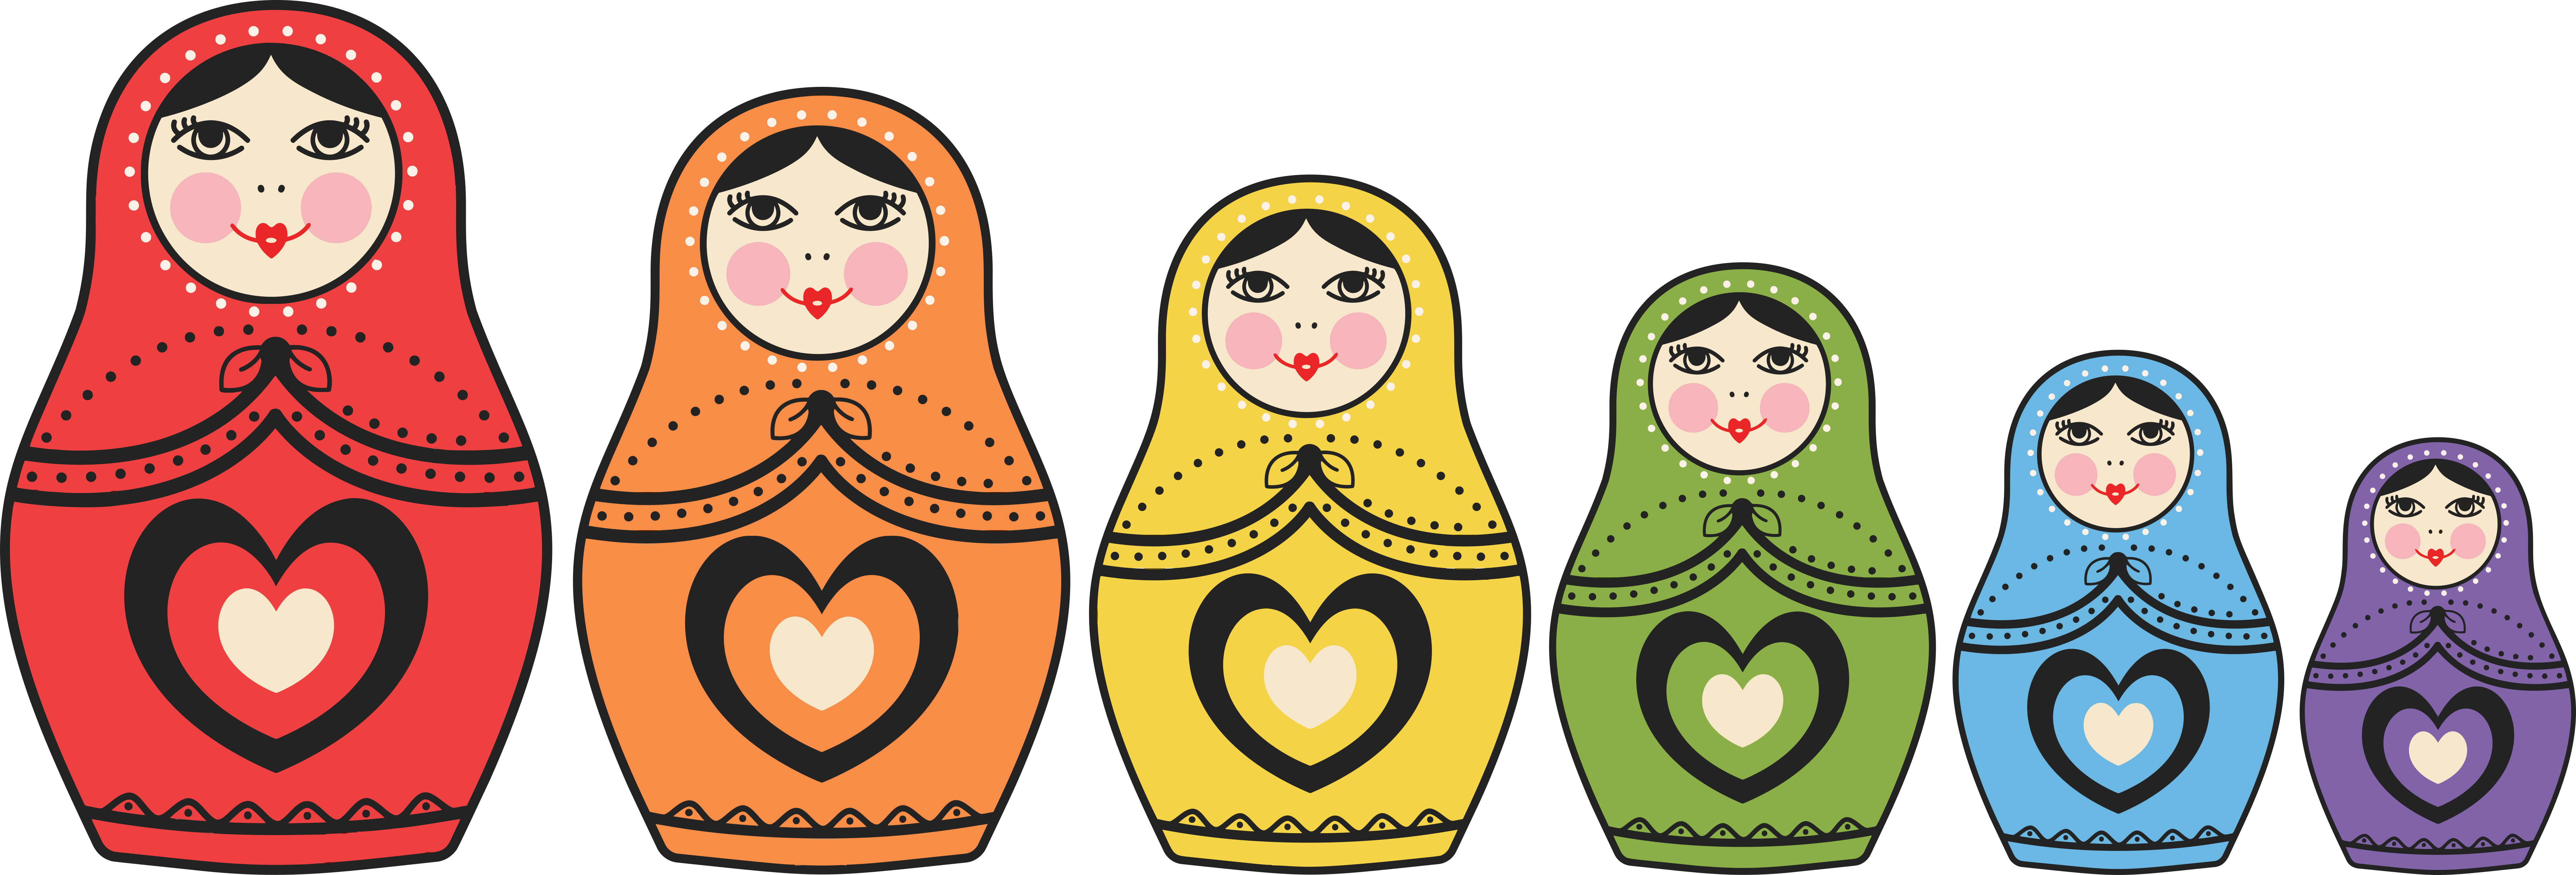

In [ ]:
from google.genai import types

texto = ["Los embeddings son representaciones vectoriales del significado."]

# Embedding con dimensionalidad completa (predeterminado: 3072)
resultado_completo = client.models.embed_content(
    model=MODEL_ID,
    contents=texto
)

# Embedding con dimensionalidad reducida (256)
resultado_reducido = client.models.embed_content(
    model=MODEL_ID,
    contents=texto,
    config=types.EmbedContentConfig(output_dimensionality=256)
)

# Embedding con dimensionalidad mínima (útil para pruebas rápidas)
resultado_mini = client.models.embed_content(
    model=MODEL_ID,
    contents=texto,
    config=types.EmbedContentConfig(output_dimensionality=10)
)

# Extraemos los embeddings
[embedding_completo] = resultado_completo.embeddings
[embedding_reducido] = resultado_reducido.embeddings
[embedding_mini] = resultado_mini.embeddings

# Comparamos las dimensiones
print(f"Dimensionalidad completa: {len(embedding_completo.values)} valores")
print(f"Dimensionalidad reducida: {len(embedding_reducido.values)} valores")
print(f"Dimensionalidad mínima: {len(embedding_mini.values)} valores")

Dimensionalidad completa: 3072 valores
Dimensionalidad reducida: 256 valores
Dimensionalidad mínima: 10 valores


El embedding de 3,072 dimensiones está normalizado. Las incorporaciones normalizadas producen una similitud semántica más precisa, ya que comparan la dirección del vector, no su magnitud. Para otras dimensiones, incluidas 768 y 1536, debes normalizar las incorporaciones de la siguiente manera:

In [ ]:
import numpy as np
from numpy.linalg import norm

embedding_values_np = np.array(embedding_reducido.values)
normed_embedding = embedding_values_np / np.linalg.norm(embedding_values_np)

print(f"Normed embedding length: {len(normed_embedding)}")
print(f"Norm of normed embedding: {np.linalg.norm(normed_embedding):.6f}") # Should be very close to 1

Normed embedding length: 256
Norm of normed embedding: 1.000000


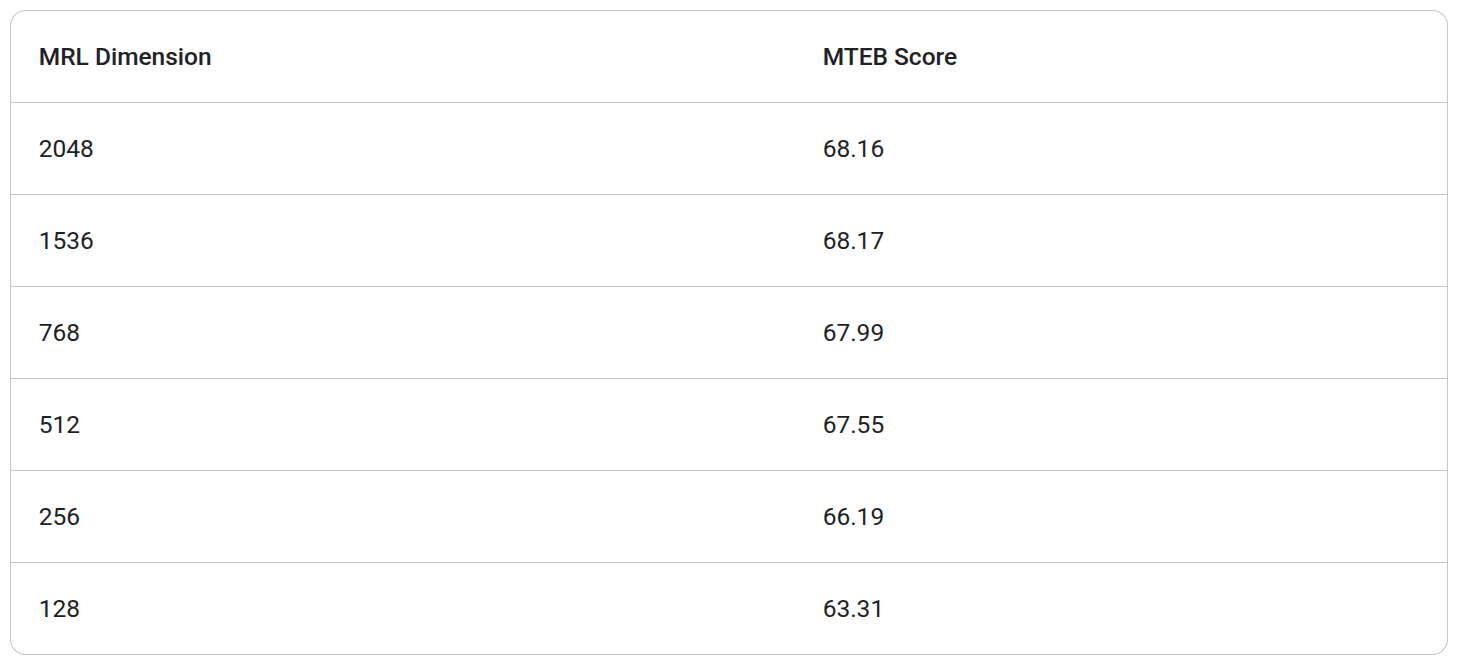

### ¿Cómo elegir la dimensionalidad adecuada?

- **Alta dimensionalidad (1024-3072)**: Mayor precisión en la representación semántica, ideal para tareas donde la calidad es crítica como sistemas RAG complejos o clasificación de textos sutilmente diferentes.
- **Media dimensionalidad (256-768)**: Buen equilibrio entre precisión y eficiencia, adecuado para la mayoría de aplicaciones prácticas.
- **Baja dimensionalidad (32-128)**: Optimizado para velocidad y almacenamiento, útil para aplicaciones en tiempo real o bases de datos muy grandes donde la eficiencia es prioritaria.

## 6. Midiendo similitud entre textos con embeddings

Una de las aplicaciones más comunes de los embeddings es medir la similitud semántica entre textos. Para esto usaremos la similitud del coseno, que mide el ángulo entre dos vectores.

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Definimos algunos textos con diferentes grados de similitud semántica
textos = [
    "Me encanta programar en Python",
    "Python es mi lenguaje de programación favorito",
    "Los perros son excelentes mascotas",
    "Disfruto mucho desarrollando software",
    "Los gatos son animales independientes"
]

# Generamos embeddings para todos los textos
resultado = client.models.embed_content(model=MODEL_ID, contents=textos)

# Extraemos los valores de los embeddings como una lista de arrays
embeddings_valores = [embedding.values for embedding in resultado.embeddings]

# Calculamos la matriz de similitud del coseno
matriz_similitud = cosine_similarity(embeddings_valores)

# Mostramos la matriz de similitud con etiquetas
import pandas as pd
similitud_df = pd.DataFrame(matriz_similitud, index=textos, columns=textos)
similitud_df

,Me encanta programar en Python,Python es mi lenguaje de programación favorito,Los perros son excelentes mascotas,Disfruto mucho desarrollando software,Los gatos son animales independientes
Me encanta programar en Python,1.000000,0.899136,0.663681,0.804536,0.589508
Python es mi lenguaje de programación favorito,0.899136,1.000000,0.640564,0.738543,0.567276
Los perros son excelentes mascotas,0.663681,0.640564,1.000000,0.643535,0.661044
Disfruto mucho desarrollando software,0.804536,0.738543,0.643535,1.000000,0.587196
Los gatos son animales independientes,0.589508,0.567276,0.661044,0.587196,1.000000


### Visualización de la similitud

Para una mejor interpretación visual, vamos a crear un mapa de calor (heatmap).

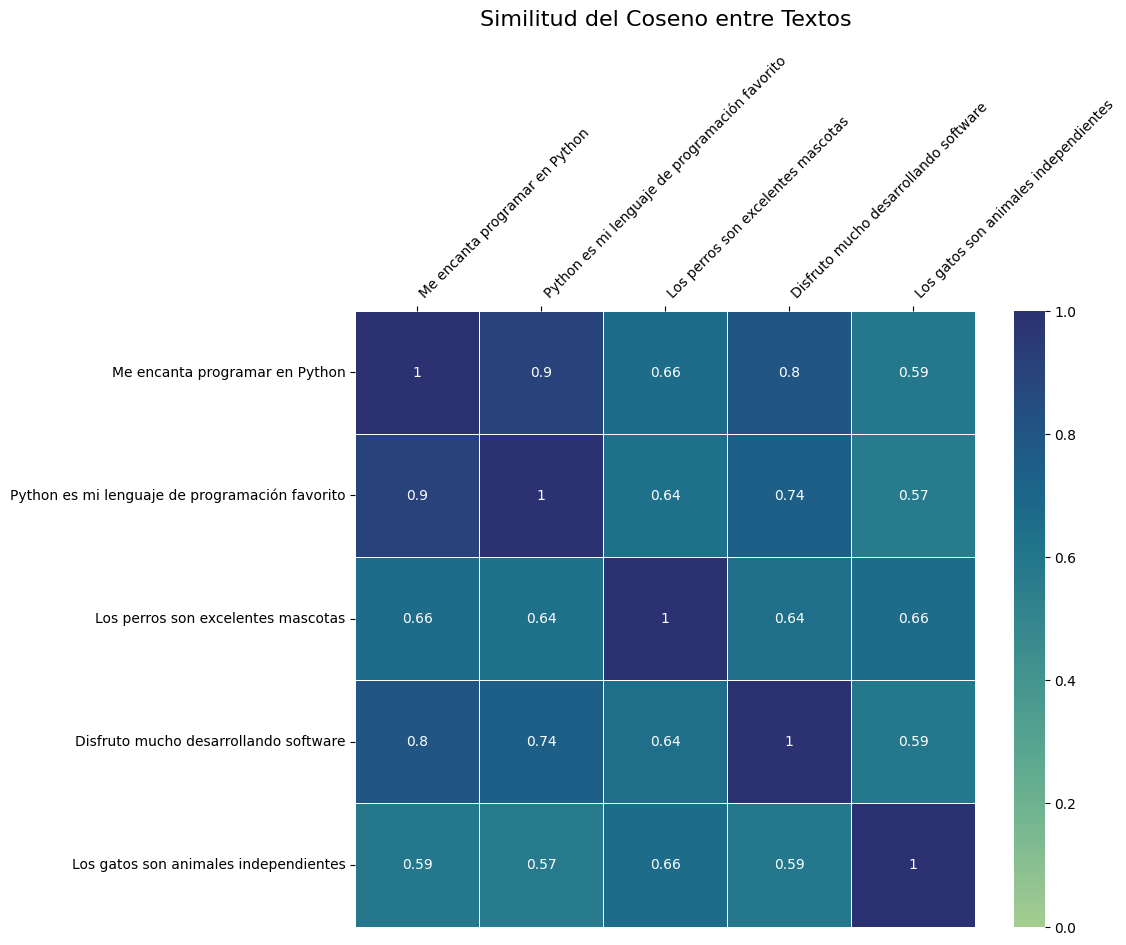

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el tamaño de la figura
plt.figure(figsize=(10, 8))

# Creamos el mapa de calor
ax = sns.heatmap(
    similitud_df,
    annot=True,               # Muestra los valores
    cmap="crest",            # Esquema de color
    vmin=0, vmax=1,           # Rango de valores
    linewidths=.5             # Líneas entre celdas
)

# Ajustamos la posición de las etiquetas
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
plt.yticks(rotation=0)

plt.title("Similitud del Coseno entre Textos", pad=20, fontsize=16)
plt.show()

### Interpretando el mapa de calor

- **Diagonal principal (valor 1.0)**: Representa la similitud de cada texto consigo mismo (siempre máxima)
- **Valores cercanos a 1.0**: Indican textos muy similares semánticamente
- **Valores cercanos a 0.0**: Indican textos muy diferentes semánticamente

Observa cómo los textos relacionados con programación tienen mayor similitud entre sí, mientras que los textos sobre mascotas tienen menor similitud con los de programación.

## 7. Tipos de tareas específicas para embeddings

Los embeddings de Google AI permiten especificar un `task_type` para optimizar los vectores generados según el caso de uso específico. Esto mejora significativamente el rendimiento en aplicaciones especializadas.

In [ ]:
# Texto de ejemplo
texto = ["¿Cuáles son los beneficios de la inteligencia artificial?"]

# Embedding para similitud semántica general
embedding_general = client.models.embed_content(
    model=MODEL_ID,
    contents=texto,
    config=types.EmbedContentConfig(task_type="SEMANTIC_SIMILARITY")
)

# Embedding optimizado para consultas de recuperación (búsqueda)
embedding_consulta = client.models.embed_content(
    model=MODEL_ID,
    contents=texto,
    config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY")
)

# Embedding optimizado para clasificación
embedding_clasificacion = client.models.embed_content(
    model=MODEL_ID,
    contents=texto,
    config=types.EmbedContentConfig(task_type="CLASSIFICATION")
)

In [ ]:
# Verificamos que los embeddings son diferentes
print(f"¿Son iguales los embeddings general y de consulta? {embedding_general.embeddings[0].values[:5] == embedding_consulta.embeddings[0].values[:5]}")
print(f"¿Son iguales los embeddings de consulta y clasificación? {embedding_consulta.embeddings[0].values[:5] == embedding_clasificacion.embeddings[0].values[:5]}")

¿Son iguales los embeddings general y de consulta? False
¿Son iguales los embeddings de consulta y clasificación? False


### Tipos de tareas disponibles

| Tipo de tarea | Descripción | Uso recomendado |
|--------------|-------------|------------------|
| `SEMANTIC_SIMILARITY` | Optimizado para comparar la similitud entre textos | Comparación directa entre textos |
| `RETRIEVAL_QUERY` | Optimizado para consultas de búsqueda | Embeddings para las consultas del usuario en sistemas RAG |
| `RETRIEVAL_DOCUMENT` | Optimizado para documentos a recuperar | Embeddings para documentos en bases de conocimiento |
| `CLASSIFICATION` | Optimizado para tareas de clasificación | Entrenamiento de clasificadores de texto |
| `CLUSTERING` | Optimizado para agrupar textos similares | Descubrimiento de temas o segmentación de datos |

## 8. Caso de uso práctico: Sistema RAG simple

Ahora implementaremos un sistema RAG (Retrieval Augmented Generation) básico para demostrar una aplicación práctica de los embeddings. Este ejemplo muestra cómo:

1. Crear embeddings para documentos con el tipo de tarea adecuado
2. Procesar una consulta del usuario como embedding
3. Encontrar el documento más relevante usando similitud del coseno
4. Generar una respuesta contextualizada con un modelo generativo

In [ ]:
# 1. Preparamos nuestra base de conocimiento con algunos documentos
documentos = [
    {
        "titulo": "Sistema de control climático",
        "contenido": "El sistema de control climático de su vehículo le permite ajustar la temperatura y flujo de aire. \
                      Para operarlo, utilice los botones y perillas ubicados en la consola central. \
                      Temperatura: La perilla de temperatura controla la temperatura dentro del vehículo. \
                      Gire la perilla en sentido horario para aumentar la temperatura o en sentido antihorario para disminuirla. \
                      Flujo de aire: La perilla de flujo de aire controla la cantidad de aire dentro del vehículo. \
                      Gire la perilla en sentido horario para aumentar el flujo de aire o en sentido antihorario para disminuirlo. \
                      Velocidad del ventilador: La perilla de velocidad del ventilador controla la velocidad del ventilador. \
                      Gire la perilla en sentido horario para aumentar la velocidad o en sentido antihorario para disminuirla."
    },
    {
        "titulo": "Pantalla táctil",
        "contenido": "Su vehículo tiene una pantalla táctil grande que proporciona acceso a diversas funciones, \
                      incluyendo navegación, entretenimiento y control del clima. \
                      Para usar la pantalla táctil, simplemente toque el icono deseado. \
                      Por ejemplo, puede tocar el icono 'Navegación' para obtener direcciones a su destino \
                      o tocar el icono 'Música' para reproducir sus canciones favoritas."
    },
    {
        "titulo": "Cambio de marchas",
        "contenido": "Su vehículo tiene una transmisión automática. \
                      Para cambiar de marcha, simplemente mueva la palanca de cambios a la posición deseada. \
                      Park (P): Esta posición se usa cuando está estacionado. Las ruedas están bloqueadas y el vehículo no puede moverse. \
                      Reverse (R): Esta posición se usa para retroceder. \
                      Neutral (N): Esta posición se usa cuando está detenido en un semáforo o en el tráfico. \
                      El vehículo no está en marcha y no se moverá a menos que presione el pedal del acelerador. \
                      Drive (D): Esta posición se usa para conducir hacia adelante. \
                      Low (L): Esta posición se usa para conducir en nieve u otras condiciones resbaladizas."
    }
]

# Convertimos a DataFrame para mejor manejo
import pandas as pd
docs_df = pd.DataFrame(documentos)

# 2. Generamos embeddings para cada documento con RETRIEVAL_DOCUMENT
docs_df["embeddings"] = docs_df.apply(
    lambda x: client.models.embed_content(
        model=MODEL_ID,
        contents=x["contenido"],
        config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT")
    ).embeddings[0].values,
    axis=1
)

# Mostramos el DataFrame con los documentos y sus embeddings
docs_df[['titulo', 'contenido']].head()

,titulo,contenido
0,Sistema de control climático,El sistema de control climático de su vehículo...
1,Pantalla táctil,Su vehículo tiene una pantalla táctil grande q...
2,Cambio de marchas,Su vehículo tiene una transmisión automática. ...


In [ ]:
# 3. Función para buscar el documento más relevante para una consulta
def encontrar_documento_relevante(consulta, dataframe, modelo):
    """Encuentra el documento más relevante para la consulta dada."""

    # Generamos el embedding para la consulta con RETRIEVAL_QUERY
    embedding_consulta = client.models.embed_content(
        model=modelo,
        contents=consulta,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY")
    )

    # Calculamos la similitud del coseno entre la consulta y todos los documentos
    similitudes = []
    for doc_embedding in dataframe.embeddings:
        # Similitud del coseno entre dos vectores
        similitud = np.dot(doc_embedding, embedding_consulta.embeddings[0].values) / \
                   (np.linalg.norm(doc_embedding) * np.linalg.norm(embedding_consulta.embeddings[0].values))
        similitudes.append(similitud)

    # Encontramos el índice del documento con mayor similitud
    indice_mejor = np.argmax(similitudes)

    # Retornamos información sobre el mejor resultado
    return {
        "documento": dataframe.iloc[indice_mejor]["contenido"],
        "titulo": dataframe.iloc[indice_mejor]["titulo"],
        "similitud": similitudes[indice_mejor],
        "todos_scores": dict(zip(dataframe.titulo, similitudes))
    }

# 4. Probamos la función con una consulta de ejemplo
consulta = "¿Cómo puedo aumentar la velocidad del ventilador en el sistema de climatización?"

resultado = encontrar_documento_relevante(consulta, docs_df, MODEL_ID)

# Mostramos los resultados
print(f"Consulta: {consulta}\n")
print(f"Documento más relevante: {resultado['titulo']}")
print(f"Puntuación de similitud: {resultado['similitud']:.4f}\n")
print("Puntuaciones de todos los documentos:")
for titulo, score in resultado['todos_scores'].items():
    print(f"- {titulo}: {score:.4f}")

Consulta: ¿Cómo puedo aumentar la velocidad del ventilador en el sistema de climatización?

Documento más relevante: Sistema de control climático
Puntuación de similitud: 0.7329

Puntuaciones de todos los documentos:
- Sistema de control climático: 0.7329
- Pantalla táctil: 0.6071
- Cambio de marchas: 0.5772


In [ ]:
# 5. Generamos una respuesta usando un modelo generativo de Gemini

# Usaremos un modelo generativo más ligero para respuestas rápidas
GENERATIVE_MODEL = "gemini-2.5-flash"

def generar_respuesta(consulta, contexto):
    """Genera una respuesta usando el modelo generativo y el contexto recuperado."""

    prompt = f"""
    Tu rol: Eres un asistente AI amigable especializado en responder preguntas sobre vehículos.

    Tu tarea: Utiliza el CONTEXTO proporcionado para responder a la PREGUNTA del usuario.

    Pautas para tu respuesta:
    - Sé claro y simple: Explica cualquier idea complicada en términos fáciles de entender.
    - Sé amigable: Escribe en un tono conversacional y cercano.
    - Sé completo: Construye una respuesta detallada utilizando toda la información relevante del contexto.
    - Céntrate en el tema: Si el contexto no contiene la respuesta, indica que la información no está disponible.

    PREGUNTA: {consulta}

    CONTEXTO: {contexto}
    """

    # Generamos la respuesta
    respuesta = client.models.generate_content(
        model=GENERATIVE_MODEL,
        contents=prompt
    )

    return respuesta.text

# Generamos una respuesta para la consulta
respuesta_final = generar_respuesta(consulta, resultado["documento"])

# Mostramos la respuesta generada
from IPython.display import Markdown
Markdown(f"**Respuesta a la consulta:**\n\n{respuesta_final}")

**Respuesta a la consulta:**

¡Claro que sí! Con gusto te explico cómo aumentar la velocidad del ventilador en el sistema de climatización de tu vehículo.

Según la información que tengo, para aumentar la velocidad del ventilador, simplemente tienes que **girar la perilla de "velocidad del ventilador" en sentido horario**.

Esta perilla está diseñada específicamente para controlar qué tan rápido sopla el aire. Así que, si quieres que el aire circule más fuerte, solo dale un giro a esa perilla hacia la derecha, ¡y listo!

## 9. Otras aplicaciones prácticas de los embeddings

Los embeddings tienen muchas aplicaciones más allá de la búsqueda semántica y los sistemas RAG. Aquí exploramos brevemente algunas de ellas.

### 9.1 Detección de anomalías en texto

Los embeddings pueden utilizarse para identificar textos que son semánticamente diferentes al resto del corpus.

In [ ]:
# Creamos un conjunto de textos relacionados con programación y uno diferente
textos_programacion = [
    "Python es un lenguaje de programación versátil y potente",
    "JavaScript es esencial para el desarrollo web moderno",
    "Los frameworks de desarrollo facilitan la creación de aplicaciones",
    "La programación orientada a objetos es un paradigma popular",
    "Los recién nacidos suelen dormir entre 14 y 17 horas al día",  # Texto anómalo
    "El control de versiones es fundamental para el trabajo en equipo",
    "Las APIs permiten la comunicación entre diferentes servicios"
]

# Generamos embeddings para todos los textos
embeddings = []
for texto in textos_programacion:
    resultado = client.models.embed_content(model=MODEL_ID, contents=[texto])
    embeddings.append(resultado.embeddings[0].values)

# Calculamos la matriz de similitud
matriz_similitud = cosine_similarity(embeddings)
similitud_df = pd.DataFrame(matriz_similitud, index=textos_programacion, columns=textos_programacion)

# Calculamos la similitud promedio de cada texto con todos los demás
similitud_promedio = []
for i in range(len(textos_programacion)):
    # Excluimos la similitud consigo mismo (que siempre es 1)
    similitudes = [matriz_similitud[i][j] for j in range(len(textos_programacion)) if i != j]
    similitud_promedio.append(sum(similitudes) / len(similitudes))

# Creamos un DataFrame con los resultados
resultados = pd.DataFrame({
    'texto': textos_programacion,
    'similitud_promedio': similitud_promedio
})

# Ordenamos por similitud promedio (menor similitud = posible anomalía)
resultados_ordenados = resultados.sort_values('similitud_promedio')
resultados_ordenados

,texto,similitud_promedio
4,Los recién nacidos suelen dormir entre 14 y 17...,0.528909
5,El control de versiones es fundamental para el...,0.600119
6,Las APIs permiten la comunicación entre difere...,0.601275
3,La programación orientada a objetos es un para...,0.603800
0,Python es un lenguaje de programación versátil...,0.619860
2,Los frameworks de desarrollo facilitan la crea...,0.622971
1,JavaScript es esencial para el desarrollo web ...,0.627723


### 9.2 Clasificación de textos

Los embeddings pueden utilizarse como features para entrenar clasificadores de texto.

In [ ]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')
newsgroups_test = fetch_20newsgroups(subset='test')

# View list of class names for dataset
newsgroups_train.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [ ]:
print(newsgroups_train.data[0])
print(newsgroups_train.target[0])

 (where's my thing)WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----





7


In [ ]:
import re
import pandas as pd

def preprocess_newsgroup_data(newsgroup_dataset):
  # Apply functions to remove names, emails, and extraneous words from data points in newsgroups.data
  newsgroup_dataset.data = [re.sub(r'[\w\.-]+@[\w\.-]+', '', d) for d in newsgroup_dataset.data] # Remove email
  newsgroup_dataset.data = [re.sub(r"", "", d) for d in newsgroup_dataset.data] # Remove names
  newsgroup_dataset.data = [d.replace("From: ", "") for d in newsgroup_dataset.data] # Remove "From: "
  newsgroup_dataset.data = [d.replace("\nSubject: ", "") for d in newsgroup_dataset.data] # Remove "\nSubject: "

  # Cut off each text entry after 5,000 characters
  newsgroup_dataset.data = [d[0:5000] if len(d) > 5000 else d for d in newsgroup_dataset.data]

  # Put data points into dataframe
  df_processed = pd.DataFrame(newsgroup_dataset.data, columns=['Text'])
  df_processed['Label'] = newsgroup_dataset.target
  # Match label to target name index
  df_processed['Class Name'] = ''
  for idx, row in df_processed.iterrows():
    df_processed.at[idx, 'Class Name'] = newsgroup_dataset.target_names[row['Label']]

  return df_processed

In [ ]:
df_train = preprocess_newsgroup_data(newsgroups_train)
df_test = preprocess_newsgroup_data(newsgroups_test)

df_train.head()

,Text,Label,Class Name
0,(where's my thing)WHAT car is this!?\nNntp-Po...,7,rec.autos
1,(Guy Kuo)SI Clock Poll - Final Call\nSummary:...,4,comp.sys.mac.hardware
2,(Thomas E Willis)PB questions...\nOrganizatio...,4,comp.sys.mac.hardware
3,(Joe Green)Re: Weitek P9000 ?\nOrganization: ...,1,comp.graphics
4,(Jonathan McDowell)Re: Shuttle Launch Questio...,14,sci.space


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11314 entries, 0 to 11313
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Text        11314 non-null  object
 1   Label       11314 non-null  int64 
 2   Class Name  11314 non-null  object
dtypes: int64(1), object(2)
memory usage: 265.3+ KB


In [ ]:
def sample_data(df, num_samples, classes_to_keep):
  df = df.groupby('Label', as_index = False).apply(lambda x: x.sample(num_samples)).reset_index(drop=True)

  df = df[df['Class Name'].str.contains(classes_to_keep)]

  # Reset the encoding of the labels after sampling and dropping certain categories
  df['Class Name'] = df['Class Name'].astype('category')
  df['Encoded Label'] = df['Class Name'].cat.codes

  return df

TRAIN_NUM_SAMPLES = 100
TEST_NUM_SAMPLES = 25
CLASSES_TO_KEEP = 'sci' # Class name should contain 'sci' in it to keep science categories
df_train = sample_data(df_train, TRAIN_NUM_SAMPLES, CLASSES_TO_KEEP)
df_test = sample_data(df_test, TEST_NUM_SAMPLES, CLASSES_TO_KEEP)


/tmp/ipython-input-1735911279.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Label', as_index = False).apply(lambda x: x.sample(num_samples)).reset_index(drop=True)
/tmp/ipython-input-1735911279.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Label', as_index = False).apply(lambda x: x.sample(num_samples)).reset_index(drop=True)


In [ ]:
import numpy as np
from tqdm.auto import tqdm
tqdm.pandas()


def make_embed_text_fn(model):

  def embed_fn(text: str) -> list[float]:
    # Set the task_type to CLASSIFICATION.
    result = client.models.embed_content(model=model,
                                            contents=text,
                                            config=types.EmbedContentConfig(
                                                task_type="CLASSIFICATION"))
    return np.array(result.embeddings[0].values)

  return embed_fn

def create_embeddings(df):
  df['Embeddings'] = df['Text'].progress_apply(make_embed_text_fn(MODEL_ID))
  return df


In [ ]:
df_train = create_embeddings(df_train)
df_train

  0%|          | 0/400 [00:00<?, ?it/s]

,Text,Label,Class Name,Encoded Label,Embeddings
1100,(Graham Toal)Re: Hard drive security for FBI ...,11,sci.crypt,0,"[-0.0026347544, 0.0006659264, 0.015786324, -0...."
1101,"(Steve Brinich)Re: Once tapped, your code is ...",11,sci.crypt,0,"[0.0019598033, 0.008031228, 0.0034722823, -0.0..."
1102,(Steven Bellovin)Re: Clipper considered harmf...,11,sci.crypt,0,"[-0.016980829, -0.003343285, 0.006113672, -0.0..."
1103,"""Jon C. R. Bennett"" <jb7m+@andrew.cmu.edu>Idea...",11,sci.crypt,0,"[-0.025213705, -0.0057339, 0.010907296, -0.037..."
1104,(Graham Toal)Re: Do we need the clipper for c...,11,sci.crypt,0,"[-0.003991766, -0.011855855, 0.0025809808, -0...."
...,...,...,...,...,...
1495,(Henry Spencer)Re: Orion drive in vacuum -- h...,14,sci.space,3,"[-0.009716356, -0.017494984, 0.011185844, -0.0..."
1496,(Phil G. Fraering)Re: PLANETS STILL: IMAGES O...,14,sci.space,3,"[0.009403761, 0.0066846535, -0.0043562753, -0...."
1497,(fred j mccall 575-3539)Re: Why not give $1 b...,14,sci.space,3,"[-0.007397728, 0.00094272266, 0.025675755, -0...."
1498,(Jon Leech)Space FAQ 07/15 - Astronomical Mne...,14,sci.space,3,"[-0.004888661, 0.01951678, -0.0004990627, -0.0..."


In [ ]:
df_test = create_embeddings(df_test)
df_test

  0%|          | 0/100 [00:00<?, ?it/s]

,Text,Label,Class Name,Encoded Label,Embeddings
275,(Steve Gardner)Re: The Escrow Database.\nNntp...,11,sci.crypt,0,"[-0.0038653861, 0.0030985347, 0.020729665, -0...."
276,Re: Key Registering Bodies\nReply-To: \nOrgani...,11,sci.crypt,0,"[-0.007440975, 0.0053077685, 0.015178851, -0.0..."
277,(Perry E. Metzger)Is this overreaction?\nOrga...,11,sci.crypt,0,"[0.030887937, 0.01025243, 0.02956236, -0.04364..."
278,(Howard S Shubs)Re: Overreacting (was Re: Onc...,11,sci.crypt,0,"[0.006385474, 0.00325876, 0.020437416, -0.0449..."
279,Theodore M.P. Lee <>Re: Hearing on 29 April 19...,11,sci.crypt,0,"[-0.037032932, -0.0036393974, 0.004650017, -0...."
...,...,...,...,...,...
370,(Pat)Re: Gamma Ray Bursters How energetic cou...,14,sci.space,3,"[0.0057426207, -0.023083556, 0.018489975, -0.0..."
371,(TS Kelso)Two-Line Orbital Element Set: Spac...,14,sci.space,3,"[-0.02190588, -0.00430968, 0.008287639, -0.050..."
372,U.K.: See Mir in Evening skies - tell friends!...,14,sci.space,3,"[-0.024973834, -0.008421026, 0.004716713, -0.0..."
373,(Larry Krumenaker)Ranking of SPACE mailing li...,14,sci.space,3,"[-0.027240017, -0.0121779, 0.008304911, -0.041..."


In [ ]:
# Preparamos los datos para un clasificador simple
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Convertimos los embeddings a una lista de listas para scikit-learn
X = list(df_train["Embeddings"])
y = df_train["Encoded Label"]

# Dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Entrenamos un clasificador simple
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluamos el clasificador
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        39
           1       0.97      1.00      0.98        30
           2       1.00      0.94      0.97        31
           3       1.00      0.97      0.98        32

    accuracy                           0.98       132
   macro avg       0.98      0.98      0.98       132
weighted avg       0.98      0.98      0.98       132



### 9.3 Función para clasificar nuevos textos

In [ ]:
clf.predict([df_test.iloc[80]["Embeddings"]])

array([3], dtype=int8)

In [ ]:
df_test.iloc[80]["Encoded Label"]

np.int8(3)

## 10. Resumen y consideraciones finales

En este tutorial, hemos explorado los embeddings de Google AI y sus aplicaciones prácticas:

1. **Fundamentos de los embeddings**: Representaciones vectoriales del significado semántico del texto
2. **Configuración y uso básico**: Cómo generar embeddings con la API de Google AI
3. **Procesamiento por lotes**: Generación eficiente de múltiples embeddings
4. **Dimensionalidad configurable**: Cómo ajustar la precisión vs. eficiencia
5. **Similitud semántica**: Cómo medir y visualizar la similitud entre textos
6. **Tipos de tareas específicas**: Optimización de embeddings para diferentes casos de uso
7. **RAG simple**: Implementación de un sistema básico de búsqueda y respuesta
8. **Aplicaciones adicionales**: Detección de anomalías y clasificación de textos

### Mejores prácticas

1. **Selecciona la dimensionalidad adecuada**: Mayor para precisión, menor para eficiencia
2. **Utiliza el tipo de tarea correcto**: Optimiza tus embeddings para tu caso de uso específico
3. **Procesa por lotes cuando sea posible**: Mejora la eficiencia y reduce costos
4. **Normaliza los vectores**: Para comparaciones de similitud más precisas
5. **Considera el almacenamiento**: Utiliza bases de datos vectoriales para colecciones grandes